In [21]:
import baltic as bt
import pandas as pd
import numpy as np

from collections import defaultdict
from collections import Counter
from itertools import combinations
import itertools


import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

import re
import random
from scipy.stats import norm


In [22]:
tree_folder = "host_trees"
clades = ['NA-avian', 'swine', 'human', 'canine', 'equine']

In [23]:
host_trees = {}

for clade in clades:
    
    tree = bt.loadNewick(f"{tree_folder}/{clade}.nwk", absoluteTime= False)
    
    host_trees[f"{clade}"] = tree
    

In [24]:
host_trees

{'NA-avian': <baltic.baltic.tree at 0x177cd7460>,
 'swine': <baltic.baltic.tree at 0x31f64d360>,
 'human': <baltic.baltic.tree at 0x32b0a0a90>,
 'canine': <baltic.baltic.tree at 0x329d72320>,
 'equine': <baltic.baltic.tree at 0x32a7a8370>}

In [25]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in host_trees.keys()}
num_segment_counts = {name: {} for name in host_trees.keys()}
leaf_list = {name: [] for name in host_trees.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in host_trees.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in host_trees.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

In [26]:
num_segment_counts

{'NA-avian': {1: 444, 2: 117, 3: 38, 4: 16, 5: 8, 6: 3, 7: 0},
 'swine': {1: 196, 2: 56, 3: 30, 4: 13, 5: 15, 6: 7, 7: 4},
 'human': {1: 5, 2: 0, 3: 2, 4: 0, 5: 1, 6: 2, 7: 0},
 'canine': {1: 6, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0},
 'equine': {1: 4, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}}

In [27]:
gene_segment_counts

{'NA-avian': {'NA': 173,
  'NP': 131,
  'NS': 100,
  'PB1': 111,
  'PB2': 117,
  'MP': 99,
  'PA': 183},
 'swine': {'NA': 59,
  'NP': 93,
  'NS': 93,
  'PB1': 63,
  'PB2': 81,
  'MP': 107,
  'PA': 99},
 'human': {'NA': 2, 'NP': 5, 'NS': 4, 'PB1': 3, 'PB2': 6, 'MP': 3, 'PA': 5},
 'canine': {'NA': 1, 'NP': 2, 'NS': 2, 'PB1': 2, 'PB2': 1, 'MP': 2, 'PA': 1},
 'equine': {'NA': 2, 'NP': 0, 'NS': 2, 'PB1': 1, 'PB2': 0, 'MP': 0, 'PA': 1}}

In [28]:
segment_pair_counts

{'NA-avian': defaultdict(<function __main__.<dictcomp>.<lambda>()>,
             {'NA': defaultdict(int,
                          {'PB1': 24,
                           'PA': 28,
                           'NP': 21,
                           'MP': 20,
                           'NS': 19,
                           'PB2': 19}),
              'PB1': defaultdict(int,
                          {'NA': 24,
                           'PA': 29,
                           'NP': 29,
                           'MP': 29,
                           'NS': 14,
                           'PB2': 26}),
              'PA': defaultdict(int,
                          {'NA': 28,
                           'PB1': 29,
                           'NP': 29,
                           'PB2': 21,
                           'NS': 19,
                           'MP': 20}),
              'NP': defaultdict(int,
                          {'NA': 21,
                           'PA': 29,
                           'PB1'

Overview:
----------

The following simulation generates a null distribution of reassortment events among influenza gene segments.

It models how often different segments and pairs of segments would be expected to appear in reassortment
events if reassortment occurred purely at random.

These simulated averages serve as a null expectation, allowing comparison to real reassortment data
to identify segments or segment pairs that co-occur more or less often than expected by chance.

Functions:
----------
1. simulate_single_run():
   - For each event size (e.g. 1, 2, 3 segments per event), randomly samples that many segments
     from the list of possible gene segments (without replacement).
   - Each draw represents a single reassortment event.
   - Returns a dictionary mapping event IDs (e.g. 'rea1', 'rea2', ...) to lists of involved segments.

2. simulate_null_distributions():
   - Runs the single-run simulation n_sims amount of times.
   - Each replicate is initialized with a unique seed (seed + i) for reproducible randomness.
   - Returns a dictionary of all replicate simulations.

3. aggregate_sim_results() and other helper functions:
   - Counts how often each segment participates in reassortments across simulations.
   - Counts how often each pair of segments co-occurs in the same event.
   - Averages these counts across all simulations to produce expected frequencies under random reassortment.

In [29]:
# helper functions for running the segment null distribution simulations

def count_segment_occurrences(events):
    """
    Count how many times each segment occurs in a set of reassortment events.
    """
    segment_counts = Counter()
    for segs in events.values():
        for seg in segs:
            segment_counts[seg] += 1
    return segment_counts

def count_cooccurrences(events):
    """
    Count pairwise co-occurrences in simulated events.
    events: dict of {rea#: [seg1, seg2, ...]}
    Returns: Counter with pairs as keys and counts as values.
    """
    pair_counts = Counter()
    for segs in events.values():
        if len(segs) > 1:  # only events with >1 segments
            # all unique pairs in the event
            for a, b in itertools.combinations(sorted(segs), 2):
                pair_counts[(a, b)] += 1
    return pair_counts


def plot_segment_counts(segment_counts, title):
    """
    Plot a bar chart of segment occurrences.
    """
    
    colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']
    
    segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
    counts = [segment_counts.get(seg, 0) for seg in segments]

    plt.figure(figsize=(10,6))
    plt.bar(segments, counts, color=plt.cm.tab20.colors[:len(segments)])
    plt.ylabel("Reassortment count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_cooccurrences(pair_counts, title):
    """
    Plot a bar chart of co-occurrence counts.
    """
    pairs = ['{},{}'.format(a, b) for (a, b) in pair_counts.keys()]
    counts = list(pair_counts.values())

    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.ylabel("Co-occurrence count")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def aggregate_sim_results(sims):
    """
    Aggregate counts of segment occurrences and co-occurrences across all simulations.
    Returns:
        avg_segment_counts: dict of average occurrences per segment
        avg_pair_counts: dict of average pairwise co-occurrences
    """
    segment_sum = Counter()
    pair_sum = Counter()
    n_sims = len(sims)

    for events in sims.values():
        seg_counts = count_segment_occurrences(events)
        pair_counts = count_cooccurrences(events)

        segment_sum.update(seg_counts) # this adds the segment counts for each simulation to each other
        
        pair_sum.update(pair_counts)

    # creating a new dictionary with the average for each segment or pairs across the simulations
    
    avg_segment_counts = {seg: count / n_sims for seg, count in segment_sum.items()}
    avg_pair_counts = {pair: count / n_sims for pair, count in pair_sum.items()}

    return avg_segment_counts, avg_pair_counts


In [32]:
def simulate_single_run(segment_counts, gene_segments, seed):
    """
    Create one simulation run for a single tree.
    Returns: {'rea1': [seg,...], 'rea2': [...], ...}
    segment_counts: dict mapping n_segments -> n_events (e.g. {1:1062, 2:286, ...})
    gene_segments: list of segment names (e.g. ['NA','NP',...])
    """
    random.seed(seed)
    events = {}
    rea_idx = 1
    
    for n_segments in sorted(segment_counts.keys()):
        
        n_events = int(segment_counts[n_segments])
        
        for _ in range(n_events):
            
            # WITHOUT replacement:
            chosen = random.sample(gene_segments, k=n_segments) # uses the seed here 

            events[f"rea{rea_idx}"] = chosen
            
            rea_idx += 1
            
    return events

def simulate_null_distributions(segment_counts, gene_segments, n_sims, seed):
    """
    Produce n_sims simulations.
    Returns: {'sim1': {...}, 'sim2': {...}, ...}
    If seed is provided, each sim gets a deterministically different seed.
    """
    sims = {}
    
    for i in range(1, n_sims + 1):
        
        sim_seed =  seed + i # each simulation gets a new seed for randomness between runs but still reproducible
        sims[f"sim{i}"] = simulate_single_run(segment_counts, gene_segments, seed=sim_seed)
    
    return sims

def compare_real_vs_null(genes, real_counts, null_avg_counts, sim_counts, host):
    """
    Compare observed segment counts to null expectations.
    Returns a DataFrame with observed, expected, difference, ratio, z-score, and p-value.
    
    sim_counts: dict of lists with counts per segment across all simulations
    """
    
    data = []
    
    for gene in genes:
        
        observed = real_counts.get(gene, 0)
        expected = null_avg_counts.get(gene, 0)
        
        # expected (null results)
        counts = sim_counts[gene] 
        mean = np.mean(counts) 

        # counts is a list of reassortment events there were for each simulation
        
        # r computes how many simulated values are as extreme or more extreme than the observed value
        # by taking the abs, it is a two-sided test based on deviation from the mean
        
        # r returns a list with len(counts) populated with True or False
        
        # np.sum sums up the Trues
        
        n = len(counts) # number of simualtions, so n = 1000
        r_mean = np.sum(np.abs(counts - mean) >= np.abs(observed - mean))
        
        p_mean = (r_mean) / (n) 
        p_mean_correction = (r_mean + 1) / (n + 1)  # small-sample correction

        p_mean_multi = p_mean * 7
        p_mean_correction_multi = p_mean_correction * 7

        if p_mean_multi > 1:
            p_mean_multi = 1.0

        if p_mean_correction_multi > 1:
            p_mean_correction_multi = 1.0
        
        data.append([gene, observed, expected, p_mean_multi, p_mean_correction_multi
                    ])
    
    df = pd.DataFrame(data, columns=['Segment', 'Observed', 'Expected', 'p val', 'p val (monte carlo correction)'])
    df['host'] = host
    return df       

Number of sims: 1000
Events in sims_NA-avian: 626


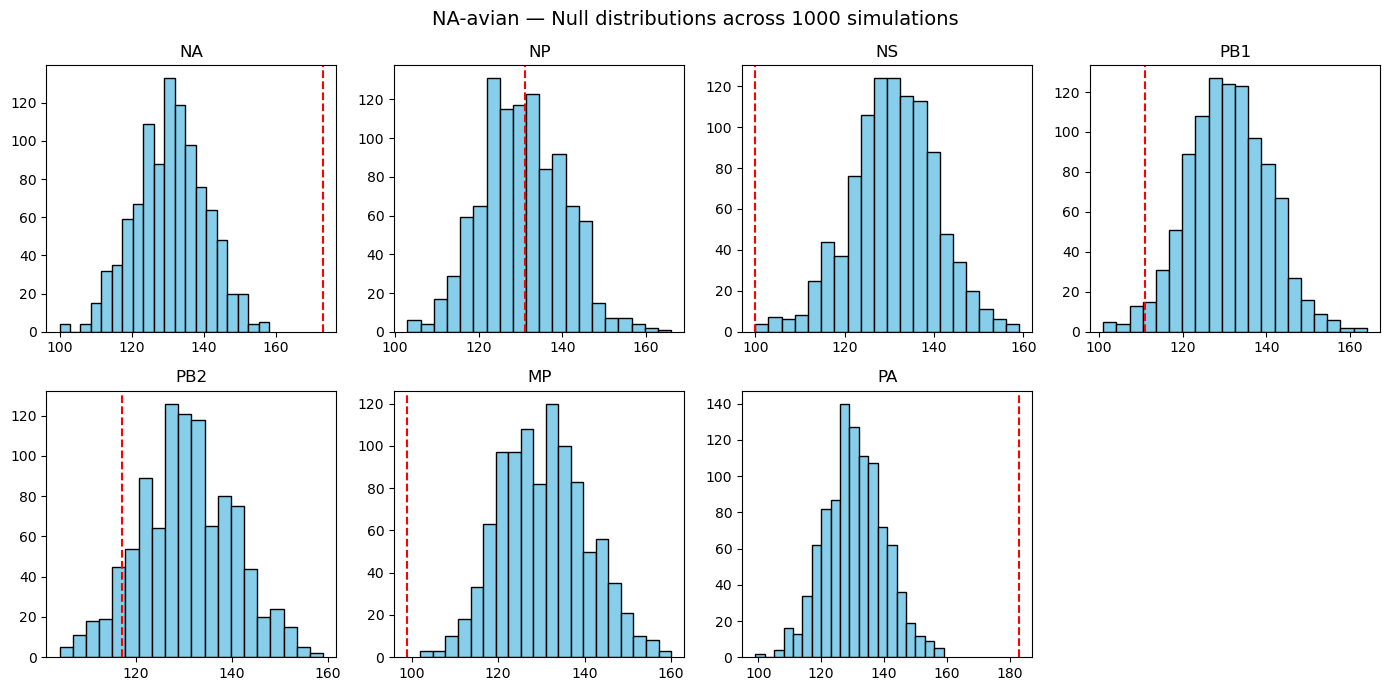

Segment  Observed      Expected       p val  p val (monte carlo correction)     host
     NA       173 130.585000000 0.000000000                     0.006993007 NA-avian
     NP       131 130.552000000 1.000000000                     1.000000000 NA-avian
     NS       100 130.901000000 0.014000000                     0.020979021 NA-avian
    PB1       111 130.931000000 0.322000000                     0.328671329 NA-avian
    PB2       117 130.381000000 1.000000000                     1.000000000 NA-avian
     MP        99 130.494000000 0.000000000                     0.006993007 NA-avian
     PA       183 130.156000000 0.000000000                     0.006993007 NA-avian
Number of sims: 1000
Events in sims_swine: 321


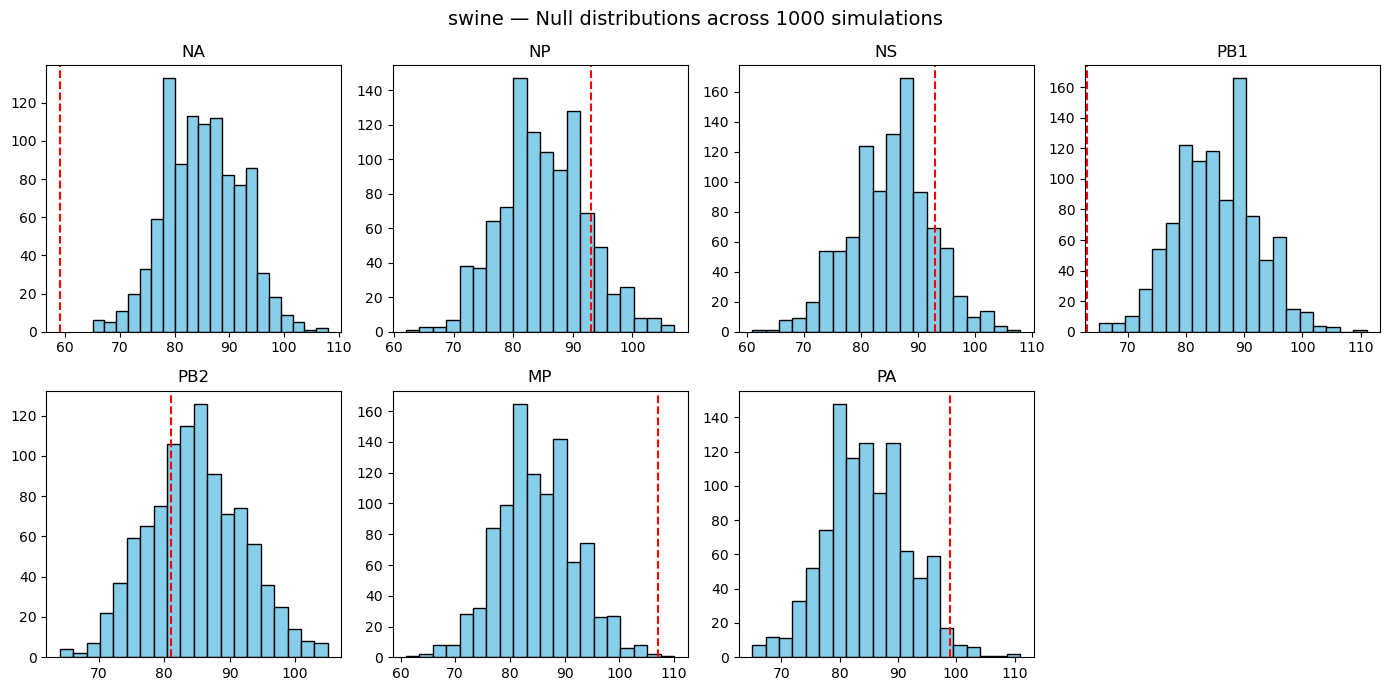

Segment  Observed     Expected       p val  p val (monte carlo correction)  host
     NA        59 85.139000000 0.000000000                     0.006993007 swine
     NP        93 84.995000000 1.000000000                     1.000000000 swine
     NS        93 85.237000000 1.000000000                     1.000000000 swine
    PB1        63 85.222000000 0.007000000                     0.013986014 swine
    PB2        81 84.778000000 1.000000000                     1.000000000 swine
     MP       107 85.012000000 0.014000000                     0.020979021 swine
     PA        99 84.617000000 0.315000000                     0.321678322 swine
Number of sims: 1000
Events in sims_human: 10


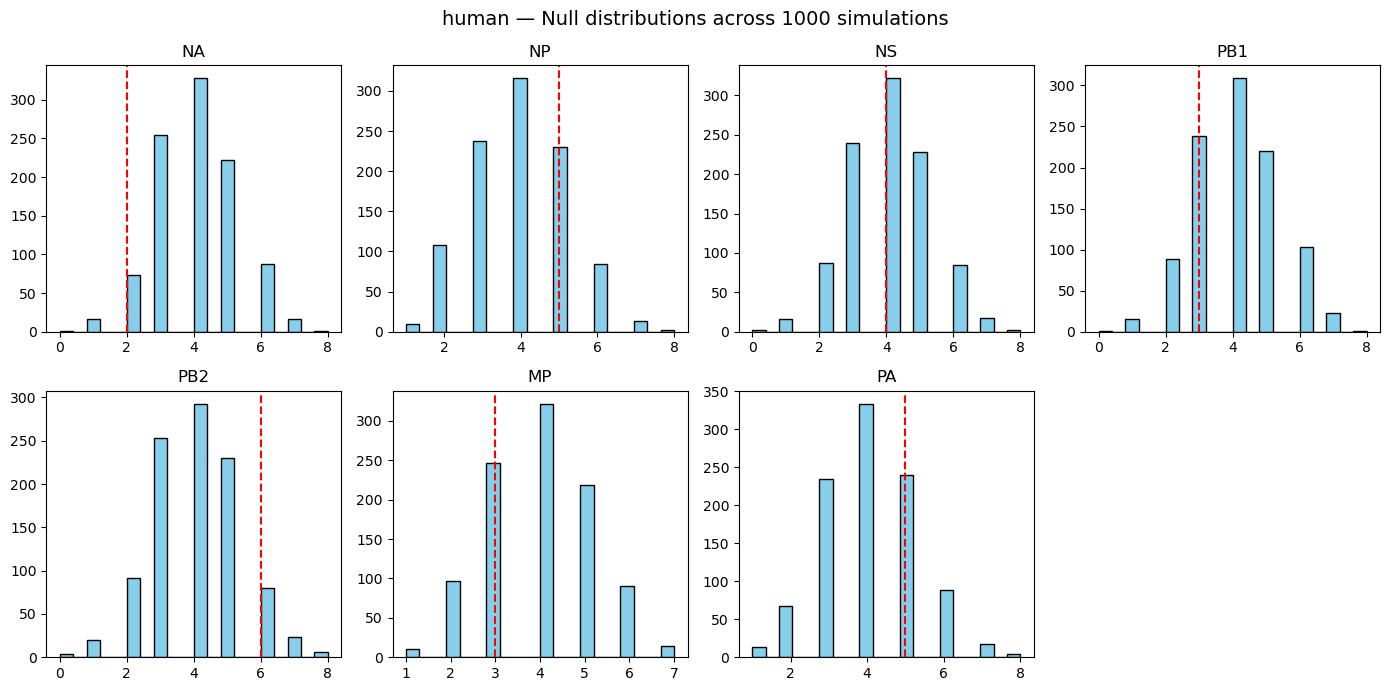

Segment  Observed    Expected       p val  p val (monte carlo correction)  host
     NA         2 4.001000000 0.756000000                     0.762237762 human
     NP         5 3.962000000 1.000000000                     1.000000000 human
     NS         4 3.990000000 1.000000000                     1.000000000 human
    PB1         3 4.033000000 1.000000000                     1.000000000 human
    PB2         6 3.972000000 0.931000000                     0.937062937 human
     MP         3 3.967000000 1.000000000                     1.000000000 human
     PA         5 4.075000000 1.000000000                     1.000000000 human
Number of sims: 1000
Events in sims_canine: 8


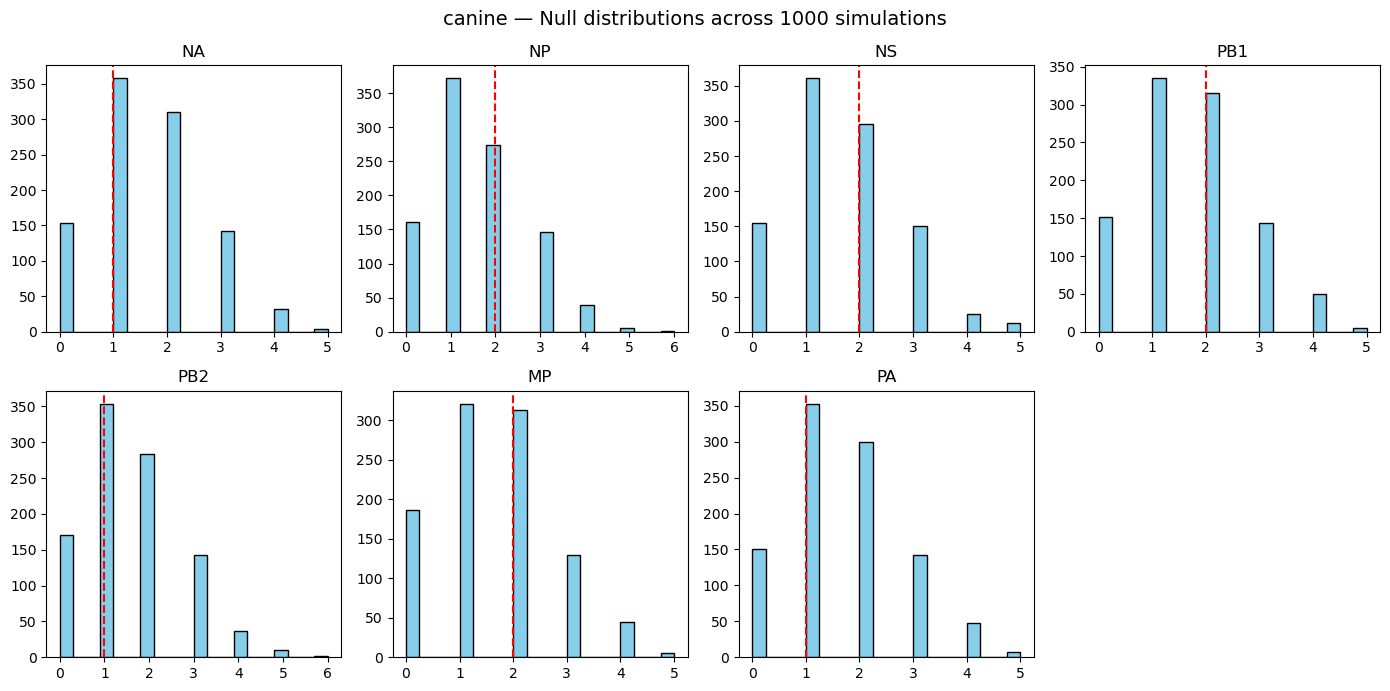

Segment  Observed    Expected       p val  p val (monte carlo correction)   host
     NA         1 1.552000000 1.000000000                     1.000000000 canine
     NP         2 1.553000000 1.000000000                     1.000000000 canine
     NS         2 1.567000000 1.000000000                     1.000000000 canine
    PB1         2 1.622000000 1.000000000                     1.000000000 canine
    PB2         1 1.558000000 1.000000000                     1.000000000 canine
     MP         2 1.544000000 1.000000000                     1.000000000 canine
     PA         1 1.604000000 1.000000000                     1.000000000 canine
Number of sims: 1000
Events in sims_equine: 5


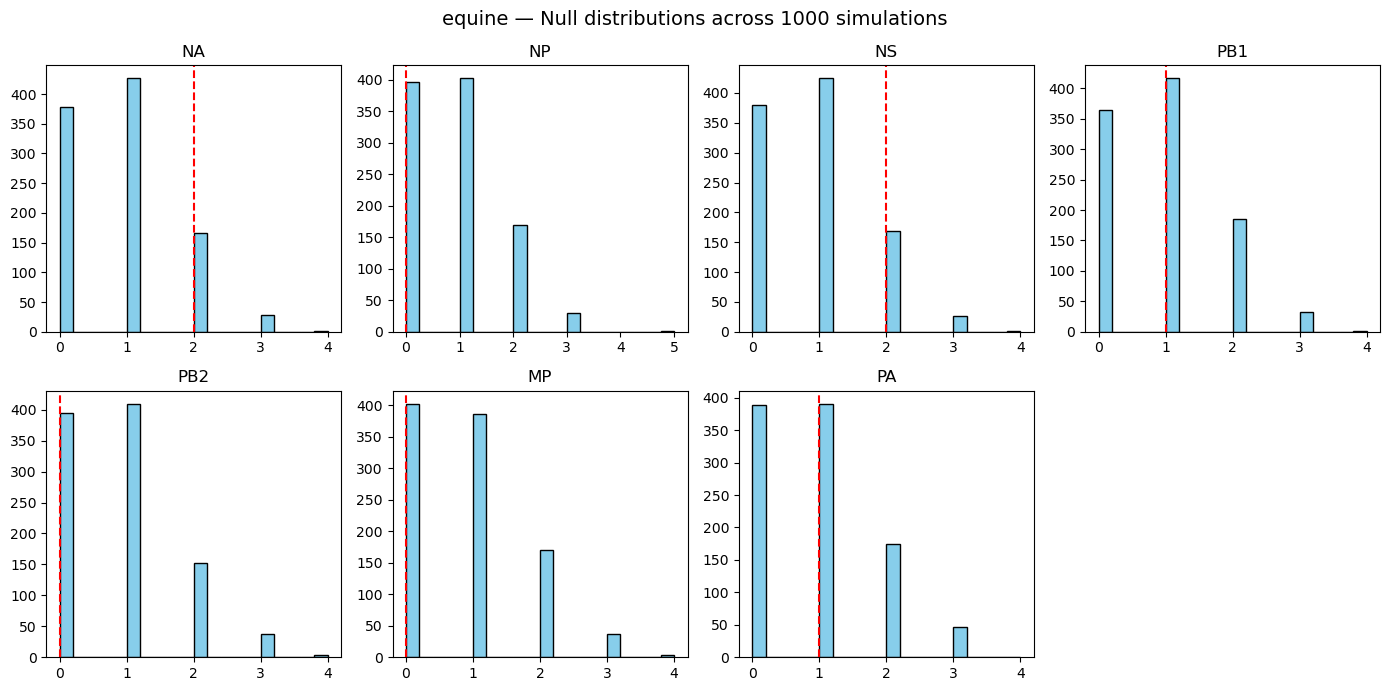

Segment  Observed    Expected       p val  p val (monte carlo correction)   host
     NA         2 0.847000000 1.000000000                     1.000000000 equine
     NP         0 0.838000000 1.000000000                     1.000000000 equine
     NS         2 0.847000000 1.000000000                     1.000000000 equine
    PB1         1 0.891000000 1.000000000                     1.000000000 equine
    PB2         0 0.846000000 1.000000000                     1.000000000 equine
     MP         0 0.850000000 1.000000000                     1.000000000 equine
     PA         1 0.881000000 1.000000000                     1.000000000 equine


In [33]:
genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for host in host_trees.keys():
    
    # each tree will get the same seed assigned ot it (51 in this case)

    sims_tree = simulate_null_distributions(num_segment_counts[host], genes, n_sims=1000, seed = 51)

    avg_segment_counts, avg_pair_counts = aggregate_sim_results(sims_tree)
    
    # quick sanity checks
    
    print("Number of sims:", len(sims_tree))
    print(f"Events in sims_{host}:", len(sims_tree['sim1']))
    
    # per-segment counts across the simulations
    # whats actually plotted for comparison to real data is the average of these counts
    sim_counts = {seg: [] for seg in genes}

    for events in sims_tree.values():
        counts = count_segment_occurrences(events) 
        for seg in genes:
            sim_counts[seg].append(counts.get(seg, 0))
            
     # plot null-distribution histograms per segment
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for i, seg in enumerate(gene_segments):
        axes[i].hist(sim_counts[seg], bins=20, color="skyblue", edgecolor="black")
        axes[i].set_title(seg)
        axes[i].axvline(gene_segment_counts[host].get(seg, 0), color="red", linestyle="--", label="Observed")
        # axes[i].legend()
    for j in range(len(gene_segments), len(axes)):  # hide any unused subplot slots
        axes[j].axis("off")
    fig.suptitle(f"{host} — Null distributions across {len(sims_tree)} simulations", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    
    comparison_df = compare_real_vs_null(gene_segments, gene_segment_counts[host], avg_segment_counts, sim_counts, host)
    
    print(comparison_df.to_string(
    index=False,
    float_format='{:.9f}'.format
    ))
